
# Project: Investigate a Dataset -No-show appointments

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

>This dataset collects information from 100k medical appointments in Brazil and is focused on the question of whether or not patients show up for their appointment. A number of characteristics about the patient are included in each row.
<ul>
<li>ScheduledDay: The day the patient went to make an appointment.</li>
<li>AppointmentDay: The day the patient should go to see the doctor</li>
<li>Neighborhood:indicates the location of the hospital.</li>
<li>Scholarship:indicates whether or not the patient is enrolled in Brasilian welfare program Bolsa Família.</li>
<li>age:patient's age.</li>
<li>Hypertension:Indicates whether the patient's blood pressure is high or not.</li>
<li>Diabetes: It shows whether the patient has diabetes or not.</li>
<li>Alcoholism: It shows whether the patient is an alcoholic or not.</li>
<li>Handcap  :Indicate whether the patient has a disability or not.</li>
<li>no_show  :Indicates whether the patient came to the appointment or not.</li>
</ul>  

#### Be careful about the encoding of the last column: it says ‘No’ if the patient showed up to their appointment, and ‘Yes’ if they did not show

### Question(s) for Analysis
>What are the factors affecting the patient’s attendance or non-attendance?
>>To find out, I'll look for the relationship between the attribute in each column and the patient's attendance at the appointment

In [1]:
# Import the libraries that I will use
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
% matplotlib inline


<a id='wrangling'></a>
## Data Wrangling

In [2]:
# Load your data and print out a few lines. Perform operations to inspect data
#   types and look for instances of missing or possibly errant data.
data=pd.read_csv('noshowappointments-kagglev2-may-2016 (2).csv')
data.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
data.shape

(110527, 14)

In [4]:
data.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


<ul>
    <li>It's strange that someone's age is -1</li>
<li>The oldest age is 115 and the average age is 37, which indicates that most patients are young and middle-aged</li>
</ul>    

In [5]:
# Checking the data type of each column as well as missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
PatientId         110527 non-null float64
AppointmentID     110527 non-null int64
Gender            110527 non-null object
ScheduledDay      110527 non-null object
AppointmentDay    110527 non-null object
Age               110527 non-null int64
Neighbourhood     110527 non-null object
Scholarship       110527 non-null int64
Hipertension      110527 non-null int64
Diabetes          110527 non-null int64
Alcoholism        110527 non-null int64
Handcap           110527 non-null int64
SMS_received      110527 non-null int64
No-show           110527 non-null object
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [6]:
# Check for duplicate rows
data.duplicated().sum()


0


### Data Cleaning

<ul>
<li>The data type problem in the column (AppointmentDay) is string and I want it to be datetime type.</li>
<li>this columns (PatientId,AppointmentID,ScheduledDay) i don't need them in my analses so l will drop them</li>
    <li>There is a problem with the age column. The youngest age is negative one,I think it is wrong, so I will drop it.</li>
</ul>

In [7]:
#I need the AppointmentDay column type to be datetime
data['AppointmentDay']=pd.to_datetime(data['AppointmentDay'])

In [8]:
# I will need a day in my analysis so I created a column for it
data['day']=data['AppointmentDay'].dt.day_name()


In [9]:
#I will drop these columns because they will not help me in the analysis because they are attached to the client
data.drop(["PatientId",'AppointmentID','ScheduledDay'],axis=1,inplace=True)


In [10]:
#In the age column there is a value of -1 I think it is wrong so I will drop it

ronge_data_2=data[data['Age'] == -1 ].index
data.drop(ronge_data_2,axis=0,inplace=True)

In [11]:
# I will change the column name No-show to No_show
data.rename(columns={'No-show':'No_show'},inplace=True)


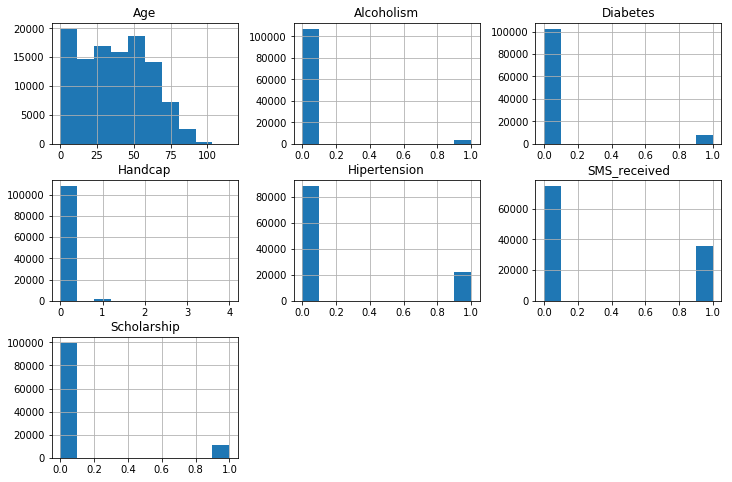

In [12]:
data.hist(figsize=(12,8));

<ul>
    <li>In general, the percentage of people who have any of these diseases is much lower than the people who do not have it</li>
    <li>Almost half of the people received a message</li>
    <li>The most common disease of these diseases is high blood pressure</li>
</ul>

<a id='eda'></a>
## Exploratory Data Analysis



### Is there a relationship between the presence of one of these diseases (diabetes, alcohol addiction, high blood pressure, disability) and the patient's attendance?

In [13]:
# I will divide the data into two parts, those who came and those who did not
come=data[data['No_show'] == 'No']
come_no=data[data['No_show']=='Yes']


In [14]:
# Does having diabetes affect attendance?
come_Diabetes=come['Diabetes'].value_counts()
come_no_Diabetes=come_no['Diabetes'].value_counts()


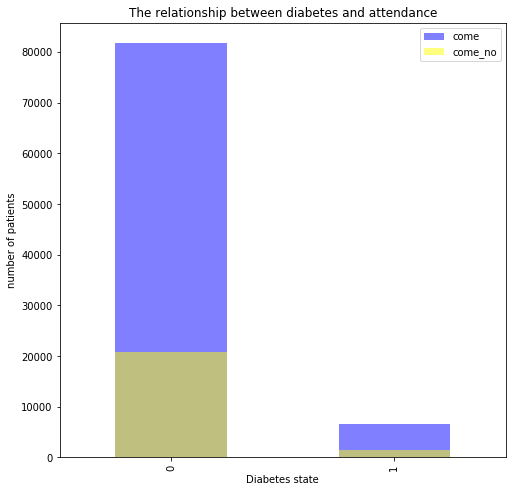

In [22]:
come_Diabetes.plot(kind='bar',alpha=0.5,color='blue',figsize=(8,8),label='come');
come_no_Diabetes.plot(kind='bar',alpha=0.5,color='yellow',figsize=(8,8),label = 'come_no');
plt.title('The relationship between diabetes and attendance');
plt.xlabel('Diabetes state');
plt.ylabel('number of patients');
plt.legend();

In [16]:
print('come_Diabetes\n',come_Diabetes)
print('come_no_Diabetes\n',come_no_Diabetes)

come_Diabetes
 0    81694
1     6513
Name: Diabetes, dtype: int64
come_no_Diabetes
 0    20889
1     1430
Name: Diabetes, dtype: int64


### Diabetes is not effective

In [17]:
# Does high blood pressure affect attendance?
come_Hipertension=come['Hipertension'].value_counts()
come_no_Hipertension=come_no['Hipertension'].value_counts()


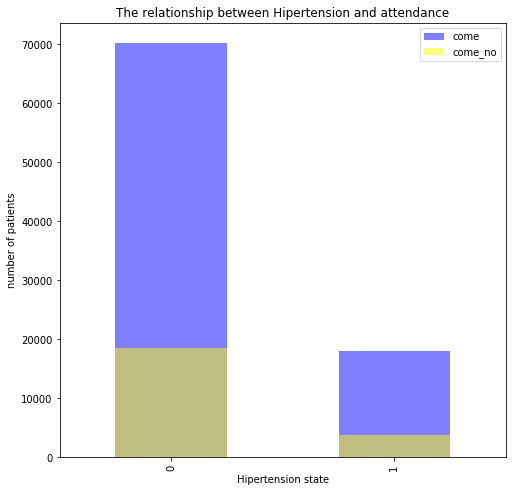

In [21]:
come_Hipertension.plot(kind='bar',alpha=0.5,color='blue',figsize=(8,8),label='come');
come_no_Hipertension.plot(kind='bar',alpha=0.5,color='yellow',figsize=(8,8),label = 'come_no');
plt.title('The relationship between Hipertension and attendance');
plt.xlabel('Hipertension state');
plt.ylabel('number of patients');
plt.legend();

In [20]:
print('come_Hipertension\n',come_Hipertension)
print('come_no_Hipertension\n',come_no_Hipertension)

come_Hipertension
 0    70178
1    18029
Name: Hipertension, dtype: int64
come_no_Hipertension
 0    18547
1     3772
Name: Hipertension, dtype: int64


### Hipertension is not effective

In [23]:
# Does alcoholism affect attendance?
come_Alcoholism=come['Alcoholism'].value_counts()
come_no_Alcoholism=come_no['Alcoholism'].value_counts()

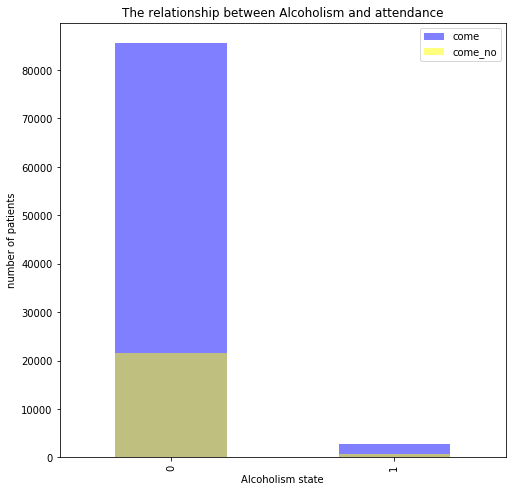

In [24]:
come_Alcoholism.plot(kind='bar',alpha=0.5,color='blue',figsize=(8,8),label='come');
come_no_Alcoholism.plot(kind='bar',alpha=0.5,color='yellow',figsize=(8,8),label = 'come_no');
plt.title('The relationship between Alcoholism and attendance');
plt.xlabel('Alcoholism state');
plt.ylabel('number of patients');
plt.legend();

In [25]:
print("come_Alcoholism\n",come_Alcoholism)
print('come_no_Alcoholism\n',come_no_Alcoholism)

come_Alcoholism
 0    85524
1     2683
Name: Alcoholism, dtype: int64
come_no_Alcoholism
 0    21642
1      677
Name: Alcoholism, dtype: int64


### Alcoholism is not effective

In [26]:
# Does disability affect attendance?
come_Handcap=come['Handcap'].value_counts()
come_no_Handcap=come_no['Handcap'].value_counts()


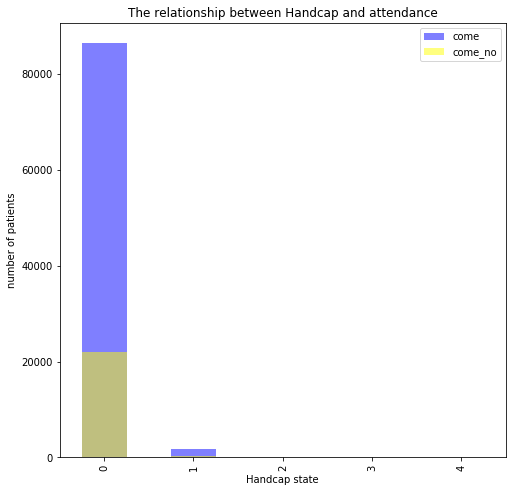

In [27]:
come_Handcap.plot(kind='bar',alpha=0.5,color='blue',figsize=(8,8),label='come');
come_no_Handcap.plot(kind='bar',alpha=0.5,color='yellow',figsize=(8,8),label = 'come_no');
plt.title('The relationship between Handcap and attendance');
plt.xlabel('Handcap state');
plt.ylabel('number of patients');
plt.legend();


In [28]:
print("come_Handcap",come_Handcap)
print("come_no_Handcap",come_no_Handcap)

come_Handcap 0    86373
1     1676
2      146
3       10
4        2
Name: Handcap, dtype: int64
come_no_Handcap 0    21912
1      366
2       37
3        3
4        1
Name: Handcap, dtype: int64


### Handcap is not effective

### Does the presence of the scholarship affect the presence of its owner?

In [29]:
come_Scholarship=come['Scholarship'].value_counts()
come_no_Scholarship=come_no['Scholarship'].value_counts()

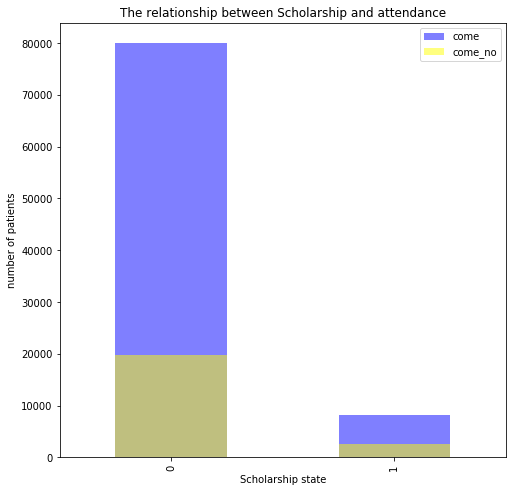

In [30]:
come_Scholarship.plot(kind='bar',alpha=0.5,color='blue',figsize=(8,8),label='come');
come_no_Scholarship.plot(kind='bar',alpha=0.5,color='yellow',figsize=(8,8),label = 'come_no');
plt.title('The relationship between Scholarship and attendance');
plt.xlabel('Scholarship state');
plt.ylabel('number of patients');
plt.legend();

In [31]:
print("come_Scholarship",come_Scholarship)
print("come_no_Scholarship",come_no_Scholarship)

come_Scholarship 0    79924
1     8283
Name: Scholarship, dtype: int64
come_no_Scholarship 0    19741
1     2578
Name: Scholarship, dtype: int64


### Scholarship is not effective

### Is there a specific hospital location where most of the appointments are not missed?

In [32]:
come_Neighbourhood=come['Neighbourhood'].value_counts()
come_no_Neighbourhood=come_no['Neighbourhood'].value_counts()

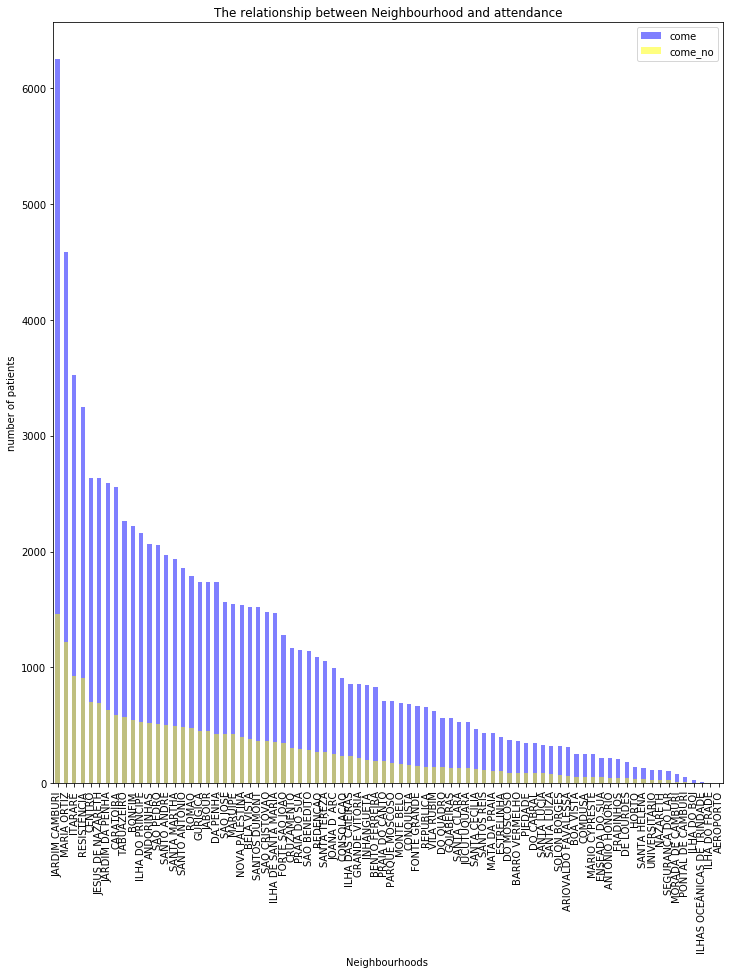

In [33]:
come_Neighbourhood.plot(kind='bar',alpha=0.5,color='blue',figsize=(12,14),label='come');
come_no_Neighbourhood.plot(kind='bar',alpha=0.5,color='yellow',figsize=(12,14),label = 'come_no');
plt.title('The relationship between Neighbourhood and attendance');
plt.xlabel('Neighbourhoods ');
plt.ylabel('number of patients');
plt.legend();

#### JARDIM CAMBURL hospitals have a high attendance rate
### There is a relationship between the presence of a patient and the Neighbourhood



### Does the patient's gender affect attendance?

In [34]:
come_gender=come['Gender'].value_counts()
come_no_gender=come_no['Gender'].value_counts()

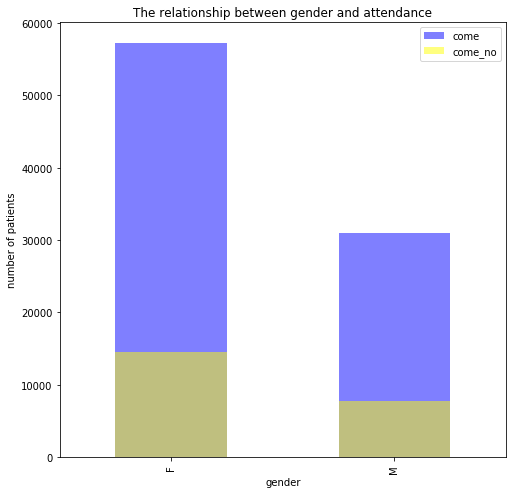

In [35]:
come_gender.plot(kind='bar',alpha=0.5,color='blue',figsize=(8,8),label='come');
come_no_gender.plot(kind='bar',alpha=0.5,color='yellow',figsize=(8,8),label = 'come_no');
plt.title('The relationship between gender and attendance');
plt.xlabel('gender');
plt.ylabel('number of patients');
plt.legend();

In [36]:
print('come_gender',come_gender)
print('come_no_gender',come_no_gender)

come_gender F    57245
M    30962
Name: Gender, dtype: int64
come_no_gender F    14594
M     7725
Name: Gender, dtype: int64


### Gender is not effective




### Does receiving a message affect attendance?

In [37]:
come_SMS_received=come['SMS_received'].value_counts()
come_no_SMS_received=come_no['SMS_received'].value_counts()

In [38]:
print('come_SMS_received\n',come_SMS_received)
print('come_no_SMS_received\n',come_no_SMS_received)

come_SMS_received
 0    62509
1    25698
Name: SMS_received, dtype: int64
come_no_SMS_received
 0    12535
1     9784
Name: SMS_received, dtype: int64


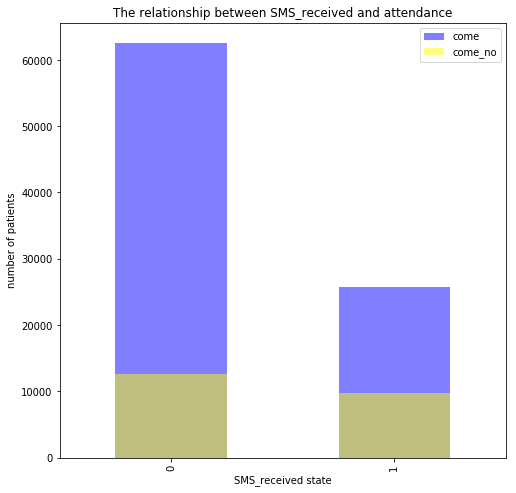

In [39]:
come_SMS_received.plot(kind='bar',alpha=0.5,color='blue',figsize=(8,8),label='come');
come_no_SMS_received.plot(kind='bar',alpha=0.5,color='yellow',figsize=(8,8),label = 'come_no');
plt.title('The relationship between SMS_received and attendance');
plt.xlabel('SMS_received state');
plt.ylabel('number of patients');
plt.legend();

### There is something strange here, the people who received a message did not come and vice versa

### Is there a day when the attendance rate is large?

In [40]:
come_day=come['day'].value_counts()
come_no_day=come_no['day'].value_counts()

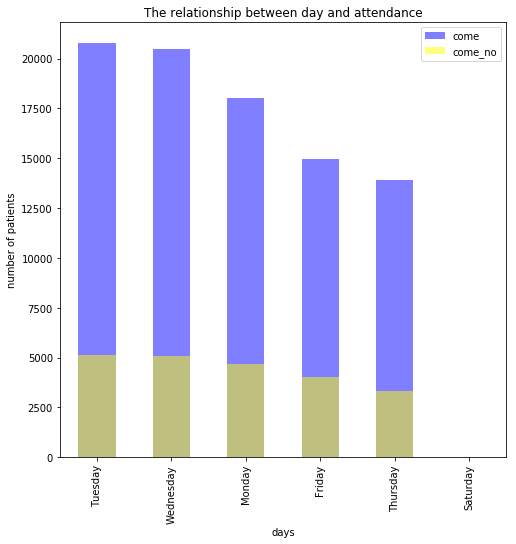

In [41]:
come_day.plot(kind='bar',alpha=0.5,color='blue',figsize=(8,8),label='come');
come_no_day.plot(kind='bar',alpha=0.5,color='yellow',figsize=(8,8),label = 'come_no');
plt.title('The relationship between day and attendance');
plt.xlabel('days');
plt.ylabel('number of patients');
plt.legend();

In [42]:
print("come_day\n",come_day)
print("come_no_day\n",come_no_day)

come_day
 Wednesday    20774
Tuesday      20488
Monday       18024
Friday       14982
Thursday     13909
Saturday        30
Name: day, dtype: int64
come_no_day
 Tuesday      5152
Wednesday    5093
Monday       4690
Friday       4037
Thursday     3338
Saturday        9
Name: day, dtype: int64


### There is a relationship between the day on which the appointment is made and the probability of attendance
### As on two days, Tuesday and Wednesday, the attendance rate is higher than the rest of the days

### Is there a relationship between the patient's age and the high attendance rate?

In [43]:
come_age=come['Age'].value_counts()
come_no_age=come_no['Age'].value_counts()


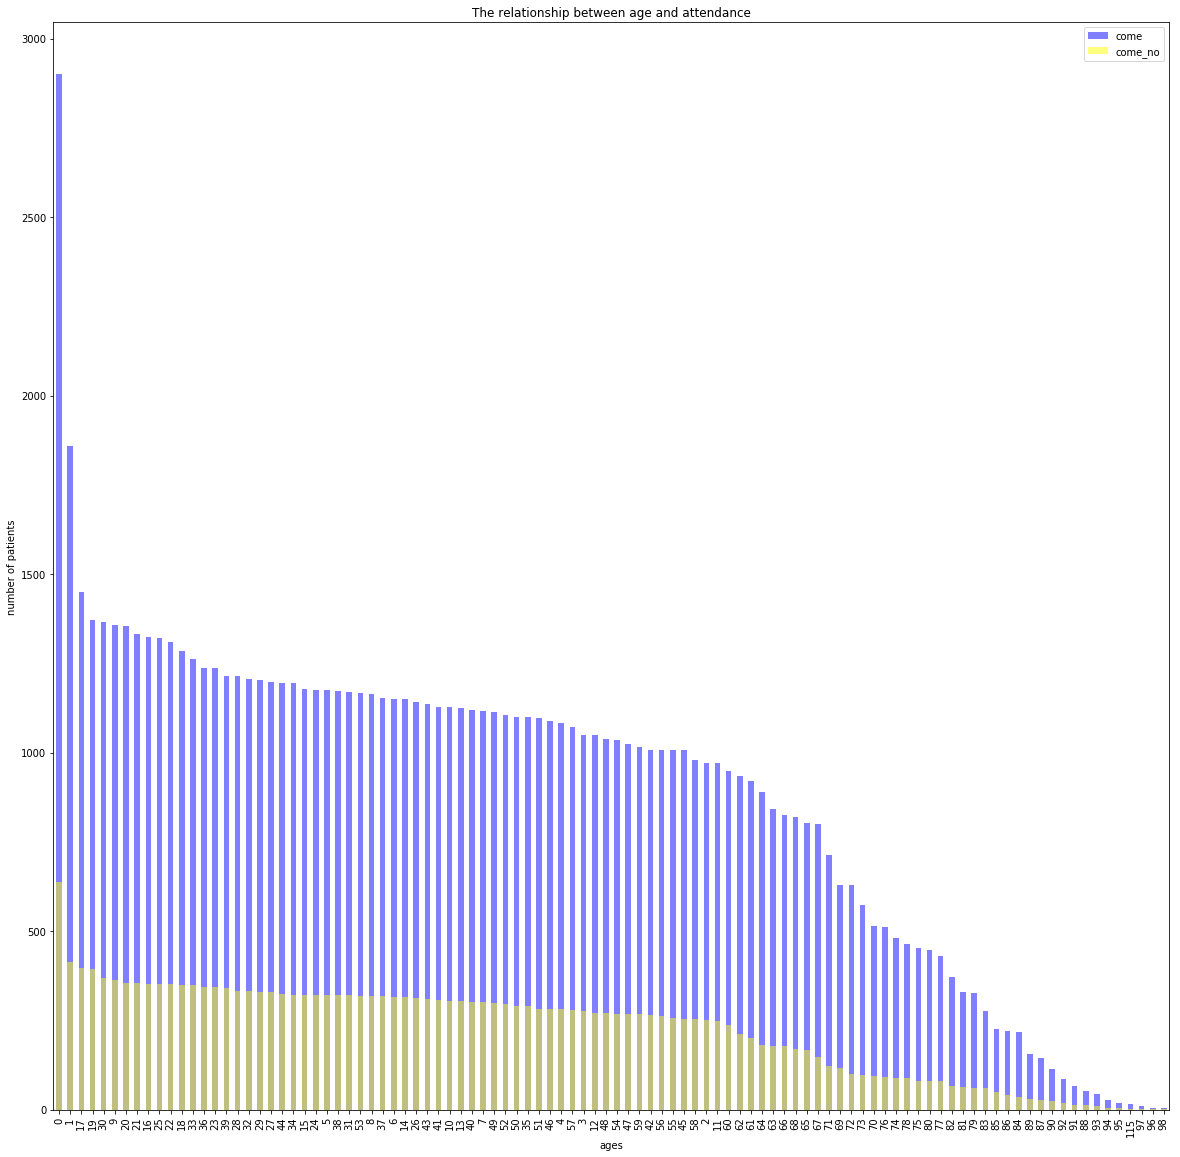

In [44]:
come_age.plot(kind='bar',alpha=0.5,color='blue',figsize=(20,20),label='come' );
come_no_age.plot(kind='bar',alpha=0.5,color='yellow',figsize=(20,20),label = 'come_no');
plt.title('The relationship between age and attendance');
plt.xlabel('ages');
plt.ylabel('number of patients');
plt.legend();


### There is a correlation between age and attendance, the younger the age, the higher the percentage of attendance

<a id='conclusions'></a>
## Conclusions
<ul>
    <li>The location of the hospital affects attendance</li>
    <li>Age affects attendance, as the lower the age, the higher the attendance rate ,vice versa</li>
    <li>Similarly, the day of the appointment affects attendance on Tuesday and Wednesday, the attendance rate is high</li>
    <li>There is a strange thing is that those who receive an SMS message do not come</li>
</ul>    

### Limitations

<ul>
    <li>The characteristics of each column are not sufficient to determine the reason for attendance or not</li>
    <li>Therefore, I think the presence of a cell that expresses when the patient comes, what is the doctor examining. Is it a digestive system, an eye, or a bone? It will help more in determining the effects in the attendance and things like this</li>
     <li>And I also think that clarifying the cases in which a message is sent to the patient may end the surprise of the result</li>
   
</ul>    


In [ ]:
from subprocess import call
call(['python', '-m', 'nbconvert', 'Investigate_a_Dataset.ipynb'])